#THE IDEA

this is the step between input and

* this is the step between input and encoder
* machines cannot process words so we transform the words via ohe
* afterwards we pad the words using a vector like 000...001 and pass the maximum capacity of words into a forward feed that is learnable
* then we get vector embedding
* but we also add positional encoding to that vector embedding and finally we get the desired vectors

#How do we get the positional embedding?




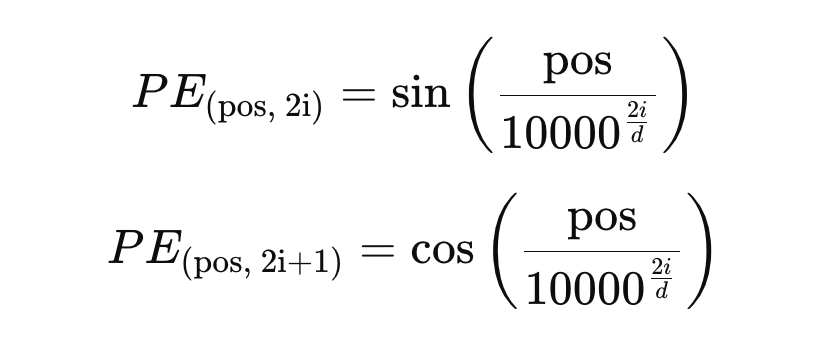

due to the formula, even_denominator and odd_denominator are the same! So we can just do one of these actions and call the resulting variable denominator

In [1]:

import torch
import torch.nn as nn

max_sequence_length = 100
d_model = 512

In [2]:

even_i = torch.arange(0, d_model, 2).float()
even_i

tensor([  0.,   2.,   4.,   6.,   8.,  10.,  12.,  14.,  16.,  18.,  20.,  22.,
         24.,  26.,  28.,  30.,  32.,  34.,  36.,  38.,  40.,  42.,  44.,  46.,
         48.,  50.,  52.,  54.,  56.,  58.,  60.,  62.,  64.,  66.,  68.,  70.,
         72.,  74.,  76.,  78.,  80.,  82.,  84.,  86.,  88.,  90.,  92.,  94.,
         96.,  98., 100., 102., 104., 106., 108., 110., 112., 114., 116., 118.,
        120., 122., 124., 126., 128., 130., 132., 134., 136., 138., 140., 142.,
        144., 146., 148., 150., 152., 154., 156., 158., 160., 162., 164., 166.,
        168., 170., 172., 174., 176., 178., 180., 182., 184., 186., 188., 190.,
        192., 194., 196., 198., 200., 202., 204., 206., 208., 210., 212., 214.,
        216., 218., 220., 222., 224., 226., 228., 230., 232., 234., 236., 238.,
        240., 242., 244., 246., 248., 250., 252., 254., 256., 258., 260., 262.,
        264., 266., 268., 270., 272., 274., 276., 278., 280., 282., 284., 286.,
        288., 290., 292., 294., 296., 29

In [3]:

even_denominator = torch.pow(10000, even_i/d_model)
even_denominator

tensor([1.0000e+00, 1.0366e+00, 1.0746e+00, 1.1140e+00, 1.1548e+00, 1.1971e+00,
        1.2409e+00, 1.2864e+00, 1.3335e+00, 1.3824e+00, 1.4330e+00, 1.4855e+00,
        1.5399e+00, 1.5963e+00, 1.6548e+00, 1.7154e+00, 1.7783e+00, 1.8434e+00,
        1.9110e+00, 1.9810e+00, 2.0535e+00, 2.1288e+00, 2.2067e+00, 2.2876e+00,
        2.3714e+00, 2.4582e+00, 2.5483e+00, 2.6416e+00, 2.7384e+00, 2.8387e+00,
        2.9427e+00, 3.0505e+00, 3.1623e+00, 3.2781e+00, 3.3982e+00, 3.5227e+00,
        3.6517e+00, 3.7855e+00, 3.9242e+00, 4.0679e+00, 4.2170e+00, 4.3714e+00,
        4.5316e+00, 4.6976e+00, 4.8697e+00, 5.0481e+00, 5.2330e+00, 5.4247e+00,
        5.6234e+00, 5.8294e+00, 6.0430e+00, 6.2643e+00, 6.4938e+00, 6.7317e+00,
        6.9783e+00, 7.2339e+00, 7.4989e+00, 7.7737e+00, 8.0584e+00, 8.3536e+00,
        8.6596e+00, 8.9769e+00, 9.3057e+00, 9.6466e+00, 1.0000e+01, 1.0366e+01,
        1.0746e+01, 1.1140e+01, 1.1548e+01, 1.1971e+01, 1.2409e+01, 1.2864e+01,
        1.3335e+01, 1.3824e+01, 1.4330e+

In [4]:
odd_i = torch.arange(1, d_model, 2).float()
odd_i


tensor([  1.,   3.,   5.,   7.,   9.,  11.,  13.,  15.,  17.,  19.,  21.,  23.,
         25.,  27.,  29.,  31.,  33.,  35.,  37.,  39.,  41.,  43.,  45.,  47.,
         49.,  51.,  53.,  55.,  57.,  59.,  61.,  63.,  65.,  67.,  69.,  71.,
         73.,  75.,  77.,  79.,  81.,  83.,  85.,  87.,  89.,  91.,  93.,  95.,
         97.,  99., 101., 103., 105., 107., 109., 111., 113., 115., 117., 119.,
        121., 123., 125., 127., 129., 131., 133., 135., 137., 139., 141., 143.,
        145., 147., 149., 151., 153., 155., 157., 159., 161., 163., 165., 167.,
        169., 171., 173., 175., 177., 179., 181., 183., 185., 187., 189., 191.,
        193., 195., 197., 199., 201., 203., 205., 207., 209., 211., 213., 215.,
        217., 219., 221., 223., 225., 227., 229., 231., 233., 235., 237., 239.,
        241., 243., 245., 247., 249., 251., 253., 255., 257., 259., 261., 263.,
        265., 267., 269., 271., 273., 275., 277., 279., 281., 283., 285., 287.,
        289., 291., 293., 295., 297., 29

In [5]:

even_denominator = torch.pow(10000, (odd_i - 1)/d_model)
even_denominator

tensor([1.0000e+00, 1.0366e+00, 1.0746e+00, 1.1140e+00, 1.1548e+00, 1.1971e+00,
        1.2409e+00, 1.2864e+00, 1.3335e+00, 1.3824e+00, 1.4330e+00, 1.4855e+00,
        1.5399e+00, 1.5963e+00, 1.6548e+00, 1.7154e+00, 1.7783e+00, 1.8434e+00,
        1.9110e+00, 1.9810e+00, 2.0535e+00, 2.1288e+00, 2.2067e+00, 2.2876e+00,
        2.3714e+00, 2.4582e+00, 2.5483e+00, 2.6416e+00, 2.7384e+00, 2.8387e+00,
        2.9427e+00, 3.0505e+00, 3.1623e+00, 3.2781e+00, 3.3982e+00, 3.5227e+00,
        3.6517e+00, 3.7855e+00, 3.9242e+00, 4.0679e+00, 4.2170e+00, 4.3714e+00,
        4.5316e+00, 4.6976e+00, 4.8697e+00, 5.0481e+00, 5.2330e+00, 5.4247e+00,
        5.6234e+00, 5.8294e+00, 6.0430e+00, 6.2643e+00, 6.4938e+00, 6.7317e+00,
        6.9783e+00, 7.2339e+00, 7.4989e+00, 7.7737e+00, 8.0584e+00, 8.3536e+00,
        8.6596e+00, 8.9769e+00, 9.3057e+00, 9.6466e+00, 1.0000e+01, 1.0366e+01,
        1.0746e+01, 1.1140e+01, 1.1548e+01, 1.1971e+01, 1.2409e+01, 1.2864e+01,
        1.3335e+01, 1.3824e+01, 1.4330e+

In [6]:

denominator = even_denominator


In [8]:
position = torch.arange(max_sequence_length, dtype=torch.float).reshape(max_sequence_length, 1)
position

tensor([[ 0.],
        [ 1.],
        [ 2.],
        [ 3.],
        [ 4.],
        [ 5.],
        [ 6.],
        [ 7.],
        [ 8.],
        [ 9.],
        [10.],
        [11.],
        [12.],
        [13.],
        [14.],
        [15.],
        [16.],
        [17.],
        [18.],
        [19.],
        [20.],
        [21.],
        [22.],
        [23.],
        [24.],
        [25.],
        [26.],
        [27.],
        [28.],
        [29.],
        [30.],
        [31.],
        [32.],
        [33.],
        [34.],
        [35.],
        [36.],
        [37.],
        [38.],
        [39.],
        [40.],
        [41.],
        [42.],
        [43.],
        [44.],
        [45.],
        [46.],
        [47.],
        [48.],
        [49.],
        [50.],
        [51.],
        [52.],
        [53.],
        [54.],
        [55.],
        [56.],
        [57.],
        [58.],
        [59.],
        [60.],
        [61.],
        [62.],
        [63.],
        [64.],
        [65.],
        [6

In [9]:

even_PE = torch.sin(position / denominator)
odd_PE = torch.cos(position / denominator)

In [12]:
print(even_PE.shape)
even_PE

torch.Size([100, 256])


tensor([[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 8.4147e-01,  8.2186e-01,  8.0196e-01,  ...,  1.1140e-04,
          1.0746e-04,  1.0366e-04],
        [ 9.0930e-01,  9.3641e-01,  9.5814e-01,  ...,  2.2279e-04,
          2.1492e-04,  2.0733e-04],
        ...,
        [ 3.7961e-01, -6.2536e-01,  7.4511e-01,  ...,  1.0805e-02,
          1.0424e-02,  1.0055e-02],
        [-5.7338e-01,  2.8505e-01, -8.9752e-02,  ...,  1.0917e-02,
          1.0531e-02,  1.0159e-02],
        [-9.9921e-01,  9.5015e-01, -8.5234e-01,  ...,  1.1028e-02,
          1.0638e-02,  1.0262e-02]])

* Now this is for positional index:
0 2 4 ....
* and odd_PE will be for:
1 3 5 ...
* We need to make it so that it is like:
0 1 2 3 4 5 ....

In [13]:

stacked = torch.stack([even_PE, odd_PE], dim=2)
stacked.shape

torch.Size([100, 256, 2])

In [14]:

PE = torch.flatten(stacked, start_dim=1, end_dim=2)
PE

tensor([[ 0.0000e+00,  1.0000e+00,  0.0000e+00,  ...,  1.0000e+00,
          0.0000e+00,  1.0000e+00],
        [ 8.4147e-01,  5.4030e-01,  8.2186e-01,  ...,  1.0000e+00,
          1.0366e-04,  1.0000e+00],
        [ 9.0930e-01, -4.1615e-01,  9.3641e-01,  ...,  1.0000e+00,
          2.0733e-04,  1.0000e+00],
        ...,
        [ 3.7961e-01, -9.2515e-01, -6.2536e-01,  ...,  9.9995e-01,
          1.0055e-02,  9.9995e-01],
        [-5.7338e-01, -8.1929e-01,  2.8505e-01,  ...,  9.9994e-01,
          1.0159e-02,  9.9995e-01],
        [-9.9921e-01,  3.9821e-02,  9.5015e-01,  ...,  9.9994e-01,
          1.0262e-02,  9.9995e-01]])

Summing it up in a Class:

In [15]:
import torch
import torch.nn as nn

class PositionalEncoding(nn.Module):

    def __init__(self, d_model, max_sequence_length):
        super().__init__()
        self.max_sequence_length = max_sequence_length
        self.d_model = d_model

    def forward(self):
        even_i = torch.arange(0, self.d_model, 2).float()
        denominator = torch.pow(10000, even_i/self.d_model)
        position = torch.arange(self.max_sequence_length).reshape(self.max_sequence_length, 1)
        even_PE = torch.sin(position / denominator)
        odd_PE = torch.cos(position / denominator)
        stacked = torch.stack([even_PE, odd_PE], dim=2)
        PE = torch.flatten(stacked, start_dim=1, end_dim=2)
        return PE


In [17]:
pe = PositionalEncoding(d_model=512, max_sequence_length=1000)
pe.forward()

tensor([[ 0.0000e+00,  1.0000e+00,  0.0000e+00,  ...,  1.0000e+00,
          0.0000e+00,  1.0000e+00],
        [ 8.4147e-01,  5.4030e-01,  8.2186e-01,  ...,  1.0000e+00,
          1.0366e-04,  1.0000e+00],
        [ 9.0930e-01, -4.1615e-01,  9.3641e-01,  ...,  1.0000e+00,
          2.0733e-04,  1.0000e+00],
        ...,
        [-8.9797e-01, -4.4006e-01,  4.2620e-01,  ...,  9.9427e-01,
          1.0317e-01,  9.9466e-01],
        [-8.5547e-01,  5.1785e-01,  9.8628e-01,  ...,  9.9425e-01,
          1.0327e-01,  9.9465e-01],
        [-2.6461e-02,  9.9965e-01,  6.9756e-01,  ...,  9.9424e-01,
          1.0337e-01,  9.9464e-01]])